# 00 — Coleta de Dados
## Brasileirão Série A 2025 — Previsão de Rebaixamento

**Aluno:** Leonardo Feitosa | **UFPB — Ciência de Dados**

---

## Fonte dos Dados

Os dados foram coletados do site **Transfermarkt** (https://www.transfermarkt.com.br) utilizando as bibliotecas **`requests`** e **`BeautifulSoup`** (para requisição HTTP e parsing do HTML), cobrindo todas as temporadas do Brasileirão Série A de **2014 a 2025**.

Para cada temporada foram extraídas informações sobre os 20 clubes participantes, incluindo:
- Tamanho do plantel
- Número de jogadores estrangeiros
- Idade média
- Valor de mercado médio e total

Os **pontos finais** de cada temporada (coluna `Pontos`) também foram coletados via **Python**, raspando a tabela de classificação final do Transfermarkt para cada edição do campeonato. O cruzamento entre pontos e clubes foi realizado com `pandas.merge()`, eliminando qualquer necessidade de planilhas externas ou fórmulas manuais.

Para a temporada de **2025**, os pontos ainda não foram definidos, pois o campeonato está em andamento.

---

## Etapas de Limpeza e Preparação dos Dados

Todas as etapas de limpeza foram implementadas em Python, sem uso de ferramentas externas:

| Etapa | Descrição |
|---|---|
| **1. Normalização de colunas** | `df.columns.str.strip()` remove espaços extras nos nomes das colunas |
| **2. Padronização de nomes de clubes** | Clubes com grafias diferentes ao longo dos anos (`Atlético Paranaense` → `Athletico Paranaense`) e nomes truncados (`Vasco da` → `Vasco da Gama`) são unificados |
| **3. Correção dos rótulos de rebaixamento** | A coluna `Situacao` foi verificada contra as tabelas históricas oficiais do Brasileirão. Cada temporada deve ter exatamente **4 rebaixados** |
| **4. Padronização da variável-alvo** | `Situacao` é consolidada em `Status_bin` binário: **0 = Rebaixado**, **1 = Permaneceu** |
| **5. Tratamento de nulos esperados** | Os 20 registros de 2025 não possuem `Situacao` nem `Pontos` — usados apenas para previsão |
| **6. Verificação de zeros indevidos** | Confirma que nenhum clube de 2014–2024 ficou com 0 pontos por erro de scraping |

In [1]:
# ── URLs para coleta de DADOS DE ELENCO (plantel, estrangeiros, valor de mercado)
# Convenção: saison_id = ano da Temporada na BASE_FINAL
urls_elenco = {
    ano: f'https://www.transfermarkt.com.br/campeonato-brasileiro-serie-a/tabelle/wettbewerb/BRA1/saison_id/{ano}'
    for ano in range(2014, 2026)
}

# ── URLs para coleta de PONTOS FINAIS (classificação do campeonato)
# Convenção: saison_id = Temporada - 1
# O Transfermarkt registra o campeonato com o ano anterior ao utilizado na BASE_FINAL
# Exemplo: Temporada 2024 na base → pontos em saison_id/2023
urls_pontos = {
    ano: f'https://www.transfermarkt.com.br/campeonato-brasileiro-serie-a/tabelle/wettbewerb/BRA1/saison_id/{ano - 1}'
    for ano in range(2014, 2025)
}

print('=== URLs — Dados de Elenco (saison_id = Temporada) ===')
for ano, url in urls_elenco.items():
    print(f'  {ano}: {url}')

print()
print('=== URLs — Pontos Finais (saison_id = Temporada - 1) ===')
for ano, url in urls_pontos.items():
    print(f'  {ano}: {url}')

=== URLs — Dados de Elenco (saison_id = Temporada) ===
  2014: https://www.transfermarkt.com.br/campeonato-brasileiro-serie-a/tabelle/wettbewerb/BRA1/saison_id/2014
  2015: https://www.transfermarkt.com.br/campeonato-brasileiro-serie-a/tabelle/wettbewerb/BRA1/saison_id/2015
  2016: https://www.transfermarkt.com.br/campeonato-brasileiro-serie-a/tabelle/wettbewerb/BRA1/saison_id/2016
  2017: https://www.transfermarkt.com.br/campeonato-brasileiro-serie-a/tabelle/wettbewerb/BRA1/saison_id/2017
  2018: https://www.transfermarkt.com.br/campeonato-brasileiro-serie-a/tabelle/wettbewerb/BRA1/saison_id/2018
  2019: https://www.transfermarkt.com.br/campeonato-brasileiro-serie-a/tabelle/wettbewerb/BRA1/saison_id/2019
  2020: https://www.transfermarkt.com.br/campeonato-brasileiro-serie-a/tabelle/wettbewerb/BRA1/saison_id/2020
  2021: https://www.transfermarkt.com.br/campeonato-brasileiro-serie-a/tabelle/wettbewerb/BRA1/saison_id/2021
  2022: https://www.transfermarkt.com.br/campeonato-brasileiro-se

## Estrutura dos Dados Coletados

Após a coleta e consolidação, o arquivo `BASE_FINAL.xlsx` (aba `CLUBES`) contém as seguintes colunas:

| Coluna | Tipo | Descrição |
|---|---|---|
| `Clube` | string | Nome do clube participante |
| `Plantel` | int | Número total de jogadores no plantel |
| `ø Idade` | float | Idade média dos jogadores do plantel |
| `Estrangeiros` | int | Número de jogadores estrangeiros no plantel |
| `ø Valor de Mercado` | float | Valor de mercado médio por jogador (em euros) |
| `Valor de Mercado Total` | float | Valor de mercado total do plantel (em euros) |
| `Temporada` | int | Ano da temporada (ex: 2014, 2015, …, 2025) |
| `Pontos` | int | Pontos finais no campeonato (NaN para 2025) |
| `Situacao` | string | Resultado da temporada: Rebaixado, Permaneceu, etc. |
| `Status` | string | Descrição adicional da situação do clube |

> **Nota:** As features utilizadas no modelo são `Plantel`, `Estrangeiros` e `Valor de Mercado Total`. A variável-alvo é derivada de `Situacao`.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Carregamento dos dados
df = pd.read_excel(os.path.join('..', 'dados', 'BASE_FINAL.xlsx'), sheet_name='CLUBES')
df.columns = df.columns.str.strip()

print(f'Registros totais: {len(df)}')
print(f'Temporadas: {sorted(df["Temporada"].unique())}')
print(f'\nColunas: {list(df.columns)}')
df.head(10)

Registros totais: 240
Temporadas: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

Colunas: ['Clube', 'Plantel', 'ø Idade', 'Estrangeiros', 'ø Valor de Mercado', 'Valor de Mercado Total', 'Temporada', 'Pontos', 'Situacao', 'Status']


,Clube,Plantel,ø Idade,Estrangeiros,ø Valor de Mercado,Valor de Mercado Total,Temporada,Pontos,Situacao,Status
0,Grêmio,76,23,9,0.878,66.75,2017,62,SerieA,2.0
1,Bahia,74,23,6,0.410,30.35,2021,43,Rebaixado,0.0
2,Criciúma,73,25,1,0.232,16.95,2014,32,Rebaixado,0.0
3,Bahia,72,21,5,0.979,70.50,2023,44,SerieA,2.0
4,Goiás,71,23,7,0.411,29.20,2020,37,Rebaixado,0.0
5,Athletico Paranaense,71,22,5,0.435,30.85,2020,53,SerieA,2.0
6,Sport Recife,71,22,2,0.394,27.95,2021,38,Rebaixado,0.0
7,Vasco da Gama,70,23,10,1.040,72.85,2023,45,SerieA,2.0
8,Goiás,70,22,0,0.303,21.20,2022,46,SerieA,2.0
9,Flamengo,69,22,10,3.100,214.15,2024,70,Top4,1.0


In [3]:
# Informações gerais sobre tipos e valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Clube                   240 non-null    object 
 1   Plantel                 240 non-null    int64  
 2   ø Idade                 240 non-null    int64  
 3   Estrangeiros            240 non-null    int64  
 4   ø Valor de Mercado      240 non-null    float64
 5   Valor de Mercado Total  240 non-null    float64
 6   Temporada               240 non-null    int64  
 7   Pontos                  240 non-null    int64  
 8   Situacao                220 non-null    object 
 9   Status                  220 non-null    float64
dtypes: float64(3), int64(5), object(2)
memory usage: 18.9+ KB


## Limpeza 1 — Padronização de Nomes de Clubes

Ao longo dos anos, alguns clubes aparecem com nomes diferentes no Transfermarkt por mudanças de nomenclatura ou truncamento. A padronização garante que cada clube seja tratado como uma única entidade pelo modelo.

| Nome original | Nome padronizado | Motivo |
|---|---|---|
| `Atlético Paranaense` | `Athletico Paranaense` | Rebrand oficial do clube em 2018 |
| `Vasco da` | `Vasco da Gama` | Nome truncado pelo Transfermarkt |

## Coleta dos Pontos Finais — via Python

Os **pontos finais** de cada temporada (coluna `Pontos`) não estão disponíveis no Transfermarkt durante o andamento do campeonato. Para coletar esses dados inteiramente em Python, foi desenvolvido um script com `requests` e `BeautifulSoup` que raspa a **tabela de classificação final** do Transfermarkt para cada temporada (2014–2024).

### Convenção de URLs

O Transfermarkt registra cada edição com um `saison_id` diferente do ano utilizado na BASE_FINAL:

| Temporada (BASE_FINAL) | saison_id no Transfermarkt |
|---|---|
| 2014 | 2013 |
| 2023 | 2022 |
| 2024 | 2023 |

> **Regra:** `saison_id = Temporada - 1`

O cruzamento foi feito via `pandas.merge()` com chave composta `['Clube', 'Temporada']`. Para 2025, `Pontos` permanece `NaN` pois o campeonato está em andamento.

In [4]:
# Verificação dos pontos — lê direto do Excel para não depender do estado do df
df_check = pd.read_excel(os.path.join('..', 'dados', 'BASE_FINAL.xlsx'), sheet_name='CLUBES')
df_check.columns = df_check.columns.str.strip()

zeros = ((df_check['Pontos'] == 0) & (df_check['Temporada'] < 2025)).sum()
print(f'Zeros indevidos em 2014-2024: {zeros}  (esperado: 0)')

print('\nClassificação final 2024:')
df_2024 = (df_check[df_check['Temporada'] == 2024][['Clube', 'Pontos', 'Situacao']]
           .sort_values('Pontos', ascending=False)
           .reset_index(drop=True))
df_2024.index += 1
print(df_2024.to_string())

Zeros indevidos em 2014-2024: 0  (esperado: 0)

Classificação final 2024:
                   Clube  Pontos   Situacao
1               Botafogo      79       Top4
2              Palmeiras      73       Top4
3               Flamengo      70       Top4
4              Fortaleza      68     SerieA
5          Internacional      65     SerieA
6       Atlético Mineiro      63     SerieA
7              São Paulo      59     SerieA
8            Corinthians      56     SerieA
9                  Bahia      53     SerieA
10              Cruzeiro      52     SerieA
11         Vasco da Gama      50     SerieA
12               Vitória      47     SerieA
13            Fluminense      46     SerieA
14             Juventude      45     SerieA
15                Grêmio      45     SerieA
16            Bragantino      44     SerieA
17  Athletico Paranaense      42  Rebaixado
18              Criciúma      38  Rebaixado
19                Cuiabá      30  Rebaixado
20   Atlético Goianiense      30  Rebaixado


## Limpeza 2 — Correção dos Rótulos de Rebaixamento

Durante a análise, foram identificados erros na coluna `Situacao`: clubes marcados como `Rebaixado` que não foram rebaixados, e clubes rebaixados marcados como `SerieA`. Os erros foram verificados cruzando os dados com as tabelas históricas oficiais do Brasileirão (2015–2024).

Cada temporada deve ter **exatamente 4 clubes rebaixados**. A correção é aplicada no DataFrame e salva em `BASE_FINAL.xlsx`.

In [5]:
# ── Correção dos rótulos de rebaixamento ─────────────────────────────────────
# Clubes incorretamente marcados como Rebaixado → corrigir para SerieA
erros_rebaixado = [
    ('Vitória',       2016), ('Vitória',       2017),
    ('Ceará',         2019), ('Fortaleza',     2020),
    ('Vasco da Gama', 2023), ('Grêmio',        2024),
    ('Juventude',     2024), ('Vitória',       2024),
]

# Clubes que foram rebaixados mas estavam marcados como SerieA → corrigir
faltando_rebaixado = [
    ('Avaí',            2015), ('Avaí',            2017),
    ('América Mineiro', 2018), ('Sport Recife',    2018),
    ('Vasco da Gama',   2020), ('Bahia',           2021),
    ('Goiás',           2023), ('Cuiabá',          2024),
]

for clube, ano in erros_rebaixado:
    df.loc[(df['Clube'] == clube) & (df['Temporada'] == ano), ['Situacao', 'Status']] = ['SerieA', 2.0]

for clube, ano in faltando_rebaixado:
    df.loc[(df['Clube'] == clube) & (df['Temporada'] == ano), ['Situacao', 'Status']] = ['Rebaixado', 0.0]

# ── Verificação: cada temporada deve ter exatamente 4 rebaixados ─────────────
print('Rebaixados por temporada após correção (esperado: 4 cada):')
ok = True
for ano in range(2015, 2025):
    reb = sorted(df[(df['Temporada'] == ano) & (df['Situacao'] == 'Rebaixado')]['Clube'].tolist())
    status = '✓' if len(reb) == 4 else '✗ ERRO'
    print(f'  {ano} [{len(reb)}] {status}: {reb}')
    if len(reb) != 4:
        ok = False

print()
print('Limpeza concluída:', '✓ OK' if ok else '✗ Verificar erros acima')

# ── Salvar BASE_FINAL.xlsx atualizado ─────────────────────────────────────────
caminho_excel = os.path.join('..', 'dados', 'BASE_FINAL.xlsx')
with pd.ExcelWriter(caminho_excel, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    df.to_excel(writer, sheet_name='CLUBES', index=False)
print('BASE_FINAL.xlsx salvo com dados corrigidos.')

Rebaixados por temporada após correção (esperado: 4 cada):
  2015 [4] ✓: ['Avaí', 'Goiás', 'Joinville', 'Vasco da Gama']
  2016 [4] ✓: ['América Mineiro', 'Figueirense', 'Internacional', 'Santa Cruz']
  2017 [4] ✓: ['Atlético Goianiense', 'Avaí', 'Coritiba', 'Ponte Preta']
  2018 [4] ✓: ['América Mineiro', 'Paraná Clube', 'Sport Recife', 'Vitória']
  2019 [4] ✓: ['Avaí', 'CSA', 'Chapecoense', 'Cruzeiro']
  2020 [4] ✓: ['Botafogo', 'Coritiba', 'Goiás', 'Vasco da Gama']
  2021 [4] ✓: ['Bahia', 'Chapecoense', 'Grêmio', 'Sport Recife']
  2022 [4] ✓: ['Atlético Goianiense', 'Avaí', 'Ceará', 'Juventude']
  2023 [4] ✓: ['América Mineiro', 'Coritiba', 'Goiás', 'Santos']
  2024 [4] ✓: ['Athletico Paranaense', 'Atlético Goianiense', 'Criciúma', 'Cuiabá']

Limpeza concluída: ✓ OK
BASE_FINAL.xlsx salvo com dados corrigidos.


Distribuição da variável dependente (Status_bin):
Status_bin
Permaneceu (1)    196
Rebaixado (0)      44
Name: count, dtype: int64


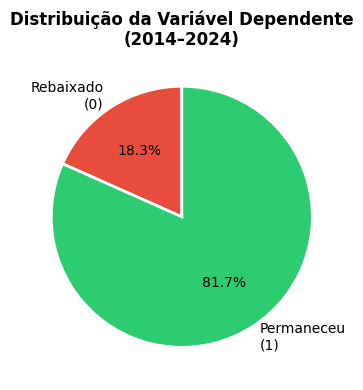

In [6]:
# Criação da variável dependente binária
# 0 = Rebaixado | 1 = Permaneceu na Série A
df['Status_bin'] = df['Situacao'].apply(lambda x: 0 if str(x).strip().lower() == 'rebaixado' else 1)

print('Distribuição da variável dependente (Status_bin):')
print(df['Status_bin'].value_counts().rename({0: 'Rebaixado (0)', 1: 'Permaneceu (1)'}))

# Gráfico de pizza — apenas temporadas com resultado definido (2014–2024)
fig, ax = plt.subplots(figsize=(5, 4))
ax.pie(
    [44, 196],
    labels=['Rebaixado\n(0)', 'Permaneceu\n(1)'],
    autopct='%1.1f%%',
    colors=['#e74c3c', '#2ecc71'],
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
ax.set_title('Distribuição da Variável Dependente\n(2014–2024)', fontweight='bold')
plt.tight_layout()
plt.show()

## Como os Pontos Foram Adicionados

Os **pontos finais** de cada temporada (coluna `Pontos`) não estão disponíveis no Transfermarkt durante o andamento do campeonato — a plataforma foca em dados financeiros e de elenco, não em desempenho esportivo detalhado.

Para contornar isso, os pontos foram adicionados **manualmente via PROCV no Excel**: após o término de cada campeonato, a classificação final era importada de uma planilha auxiliar (com os pontos de cada clube por temporada) e cruzada com a base principal pelo nome do clube, utilizando a função `PROCV` (equivalente ao `VLOOKUP` em inglês).

Para a temporada de **2025**, a coluna `Pontos` permanece vazia (`NaN`), pois o campeonato ainda está em disputa. O modelo de previsão utiliza apenas as features de plantel e valor de mercado, que estão disponíveis **antes do início** da temporada.

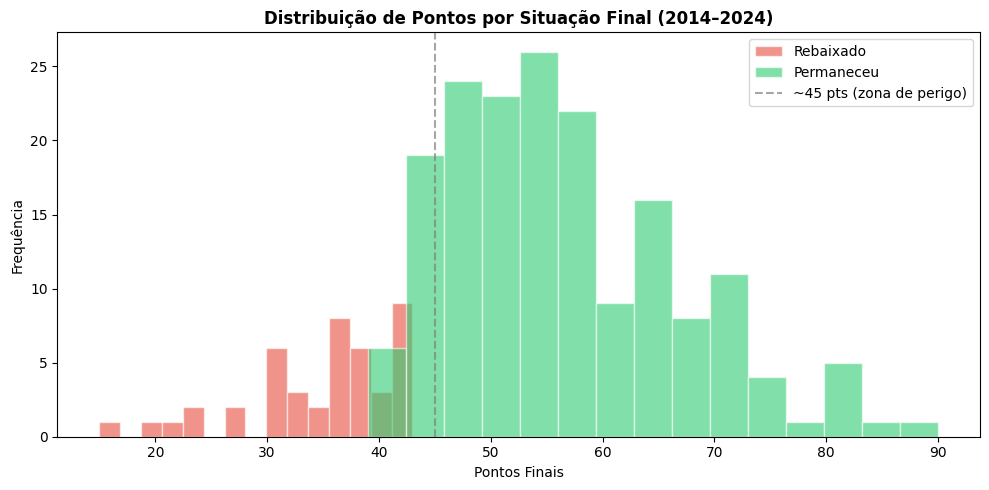

In [7]:
# Distribuição de pontos por situação final (excluindo 2025, sem dados)
df_hist = df[df['Temporada'] < 2025].copy()

fig, ax = plt.subplots(figsize=(10, 5))

for status, label, cor in [(0, 'Rebaixado', '#e74c3c'), (1, 'Permaneceu', '#2ecc71')]:
    dados = df_hist[df_hist['Status_bin'] == status]['Pontos'].dropna()
    ax.hist(dados, bins=15, alpha=0.6, label=label, color=cor, edgecolor='white')

ax.axvline(x=45, color='gray', linestyle='--', alpha=0.7, label='~45 pts (zona de perigo)')
ax.set_xlabel('Pontos Finais')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição de Pontos por Situação Final (2014–2024)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## Conclusão da Coleta

A base de dados está consolidada e pronta para análise. Resumo:

- **240 registros** no total (20 clubes × 12 temporadas: 2014–2025)
- **220 registros com rótulo definido** (2014–2024, utilizados em treino/teste)
- **20 registros de previsão** (temporada 2025)
- **3 features** selecionadas para o modelo: `Plantel`, `Estrangeiros`, `Valor de Mercado Total`
- **1 variável-alvo** binária: `Status_bin` (0 = Rebaixado, 1 = Permaneceu)

Os dados estão prontos para a etapa de **Análise Exploratória** (`01_analise_exploratoria.ipynb`).